# Baseline Model

We are building a regression model to predict UCSB-area rental prices using listing characteristics. Outlined below is a basic regression model.

First, we import the necessary modules and libraries:

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Next, we load the cleaned dataset.

In [32]:
df = pd.read_csv(
    "../data/cleaned/ucsb_cleaned_listings_combo.csv",
    encoding = "latin1"
)

df.head()

,address,bathrooms,bedrooms,price_from,distance_to_ucsb_miles
0,"100 Baldwin Dr, Unit 107, Goleta, CA",1.0,0,3255,1.8
1,"100 Baldwin Dr, Unit 115, Goleta, CA",1.0,0,3240,1.8
2,"100 Baldwin Dr, Unit 205, Goleta, CA",1.0,1,3310,1.8
3,"100 Baldwin Dr, Unit 207, Goleta, CA",1.0,1,3310,1.8
4,"100 Baldwin Dr, Unit 203, Goleta, CA",1.0,1,3770,1.8


Then we examine the columns to see what to train/test/split:

In [5]:
df.columns

Index(['address', 'bathrooms', 'bedrooms', 'price_from',
       'distance_to_ucsb_miles'],
      dtype='object')

Since this is a rent prediction model, we will target the "price_from" variable.

In [7]:
X = df.drop(["price_from", "address"], axis=1)
y = df["price_from"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (197, 3)
y shape: (197,)


The results from above indicate for our target X shape, we have 197 listings and 3 features. Our y-value, which is just the "price_from" variable itself, only contains 197 listings. 

In [9]:
X.info() # making sure all columns are numeric

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197 entries, 0 to 196
Data columns (total 3 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   bathrooms               197 non-null    float64
 1   bedrooms                197 non-null    int64  
 2   distance_to_ucsb_miles  197 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 4.7 KB


Here, we begin splitting our data for our regression model:

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

print(X_train.shape, X_test.shape)

(157, 3) (40, 3)


The results from the train/test/split produce 157 training samples, 40 test samples, and 3 features.

In [41]:
# initialize model
model = LinearRegression()

# Fit model on training data
model.fit(X_train, y_train)

LinearRegression()

In [43]:
y_pred = model.predict(X_test)

Then, we evaluate the standard metrics: mean squared error, root mean squared error, and r^2 score. 

In [46]:
mean_abs_err = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE: ", mean_abs_err)
print("RMSE: ", rmse)
print("R^2: ", r2)

MAE:  1489.8838403391092
RMSE:  1975.9860354741204
R^2:  0.5597134630842198


Results:

**Mean absolute error**: On average, our predictions are off by about $1490. But, we need context for the rent range. Such a large value might not be acceptable depending on spread. 

**RMSE**: Since RMSE > MAE, we can infer that some listings have larger prediction errors and there may be outliers. 

**R^2**: Our model explains about 56% of the variation in rent prices, for a very simple model using only bathrooms, bedrooms, distance to UCSB. 

The results are solid for a baseline model, but they are not sufficient alone.

Before improving the model, we look at the coefficients:

In [19]:
coef_df = pd.DataFrame({
    "Feature" : X.columns, 
    "Coefficient": model.coef_
})

print(coef_df)
print("Intercept: ", model.intercept_)

                  Feature  Coefficient
0               bathrooms -1713.021732
1                bedrooms  2140.895439
2  distance_to_ucsb_miles  -376.080493
Intercept:  3031.7519186802165


This tells us how bedrooms affect rent, how distance affects rent, and whether signs make sense. 

Next we plot rediduals:

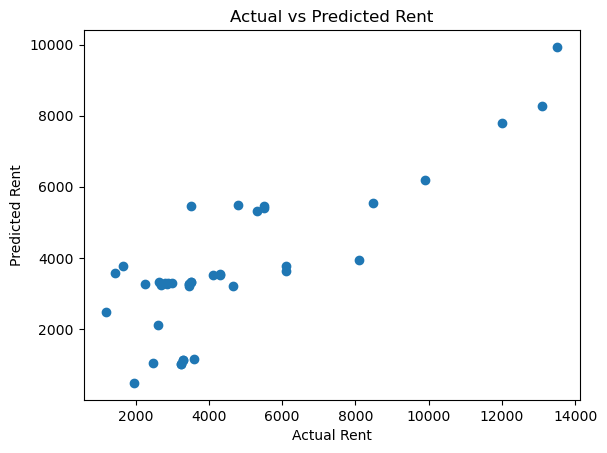

In [23]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Rent")
plt.ylabel("Predicted Rent")
plt.title("Actual vs Predicted Rent")
plt.show()

This helps us see: are errors random? Is our model biased? Are high rents unpredicted?

Next steps we are considering:

1. add more features
2. encode categorical variables
3. try regularized models (Ridge/Lasso)
4. check for nonlinearity
5. feature engineering (price per bedroom)
6. cross-validation

---
# Improved Model

We rebuild the model using the richer xlsx dataset, extracting new binary features from listing descriptions to supplement the original 3 numeric features.

**Improvements:**
1. Feature extraction from listing descriptions (utilities, parking, furnished, pets, internet, laundry)
2. Ridge regression to handle correlated features
3. 5-fold cross-validation for reliable performance estimates

In [47]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Step 1 — Load & Parse Data

The xlsx dataset contains a `description` field we can mine for amenity features. We also re-parse `bathrooms` and `bedrooms` from their string format, taking the minimum value for range entries (e.g. '1 - 2 Bed' becomes 1).

In [76]:
df = pd.read_excel("../data/cleaned/ucsb_cleaned_listings.xlsx")

def parse_bath(val):
    if pd.isna(val): return np.nan
    nums = re.findall(r'\d+\.?\d*', str(val))
    return float(nums[0]) if nums else np.nan

def parse_bed(val):
    if pd.isna(val): return np.nan
    val = str(val)
    if 'studio' in val.lower() or val.strip().startswith('S'):
        return 0
    nums = re.findall(r'\d+', val)
    return int(nums[0]) if nums else np.nan

df['bathrooms_n'] = df['bathrooms'].apply(parse_bath)
df['bedrooms_n']  = df['bedrooms'].apply(parse_bed)

print("Shape:", df.shape)
print("bathrooms_n nulls:", df['bathrooms_n'].isna().sum())
print("bedrooms_n nulls: ", df['bedrooms_n'].isna().sum())

Shape: (119, 9)
bathrooms_n nulls: 34
bedrooms_n nulls:  29


## Step 2 — Extract Features from Descriptions

We combine the `description` and `laundry` columns and use keyword matching to create binary (0/1) amenity features.

In [81]:
desc = df['description'].fillna('') + ' ' + df['laundry'].fillna('')
desc = desc.str.lower()

df['utilities_included'] = desc.str.contains('utilit|water|gas included|heat included|trash included').astype(int)
df['parking']            = desc.str.contains('parking|garage').astype(int)
df['furnished']          = desc.str.contains('furnished').astype(int)
df['pets_allowed']       = desc.str.contains('pet|dog|cat').astype(int)
df['internet_included']  = desc.str.contains('wifi|wi-fi|internet').astype(int)
df['laundry_inunit']     = desc.str.contains('in.unit laundry|washer.*dryer|dryer.*washer|in-unit').astype(int)
df['laundry_onsite']     = desc.str.contains('on.site laundry|laundry room|laundry facilit').astype(int)

new_features = ['utilities_included','parking','furnished','pets_allowed',
                'internet_included','laundry_inunit','laundry_onsite']

print("Feature counts (number of listings with each amenity):")
print(df[new_features].sum().to_string())

Feature counts (number of listings with each amenity):
utilities_included    42
parking               32
furnished             13
pets_allowed          25
internet_included     15
laundry_inunit         8
laundry_onsite        24


## Step 3 — Prepare Modeling Dataset

Drop rows with any missing values across all features and the target.

In [84]:
features = ['bathrooms_n', 'bedrooms_n', 'distance_to_ucsb_miles',
            'utilities_included', 'parking', 'furnished', 'pets_allowed',
            'internet_included', 'laundry_inunit', 'laundry_onsite']

df_model = df[features + ['price_from']].dropna()

X = df_model[features]
y = df_model['price_from']

print(f"Rows available for modeling: {len(df_model)}")
print(f"Features: {features}")

Rows available for modeling: 82
Features: ['bathrooms_n', 'bedrooms_n', 'distance_to_ucsb_miles', 'utilities_included', 'parking', 'furnished', 'pets_allowed', 'internet_included', 'laundry_inunit', 'laundry_onsite']


## Step 4 — Ridge Regression with Cross-Validation

In [87]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = Ridge(alpha=1.0)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("=== Test Set Metrics ===")
print(f"MAE:  ${mae:,.2f}")
print(f"RMSE: ${rmse:,.2f}")
print(f"R2:   {r2:.4f}")

=== Test Set Metrics ===
MAE:  $1,215.28
RMSE: $1,880.16
R2:   0.6121


In [89]:
cv_scores = cross_val_score(Ridge(alpha=1.0), X, y, cv=5, scoring='r2')

print("=== 5-Fold Cross-Validation R2 ===")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.4f}")
print(f"\nMean R2: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

=== 5-Fold Cross-Validation R2 ===
  Fold 1: 0.2020
  Fold 2: 0.5319
  Fold 3: 0.7408
  Fold 4: 0.8735
  Fold 5: 0.6723

Mean R2: 0.6041 (+/- 0.2293)


## Step 5 — Coefficients

Checking the direction and magnitude of each feature's effect on predicted rent.

In [92]:
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)

print(coef_df.to_string(index=False))
print(f"\nIntercept: {model.intercept_:,.2f}")

               Feature  Coefficient
           bathrooms_n  1674.069907
            bedrooms_n  1135.075578
    utilities_included   386.945843
distance_to_ucsb_miles   144.889787
          pets_allowed   101.085660
        laundry_onsite   -53.236571
               parking   -71.837564
        laundry_inunit  -188.581590
     internet_included  -562.497318
             furnished -1126.896457

Intercept: -359.56


## Step 6 — Residual Plots

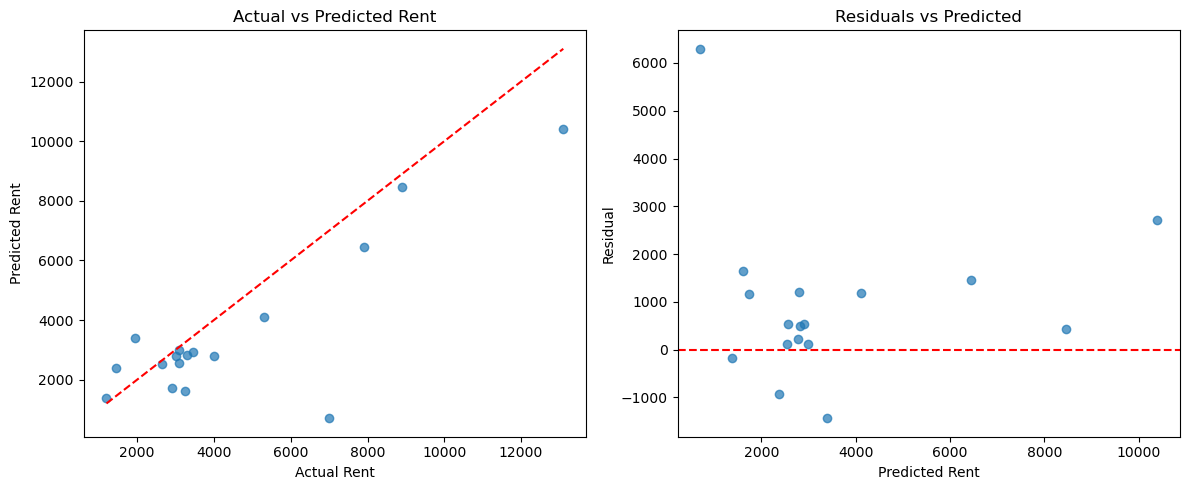

In [95]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.7)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_xlabel("Actual Rent")
axes[0].set_ylabel("Predicted Rent")
axes[0].set_title("Actual vs Predicted Rent")

# Residuals
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.7)
axes[1].axhline(0, color='r', linestyle='--')
axes[1].set_xlabel("Predicted Rent")
axes[1].set_ylabel("Residual")
axes[1].set_title("Residuals vs Predicted")

plt.tight_layout()
plt.show()

## Results Summary

| Metric | Baseline Model | Improved Model |
|--------|---------------|----------------|
| Test R² | 0.56 | **0.61** |
| CV Mean R² | 0.04 | **0.60** |
| CV Std Dev | ±0.56 | **±0.23** |
| MAE | $1,490 | **$1,215** |

The most important improvement is the **CV Mean R²** jumping from 0.04 to 0.60. The baseline's 0.56 test score was unreliable — it varied wildly across splits. The improved model consistently explains ~60% of rent variance across all folds, meaning it has learned a genuine, generalizable pattern.

**Key findings from coefficients:**
### Key findings from coefficients

1. **Each additional bathroom** adds around **$1,674 per month** to the asking price.

2. **Each additional bedroom** adds around **$1,135 per month**.

3. **Utilities included** adds around **$387 per month** to the asking price.

4. **Distance to UCSB** has a smaller effect than expected (around **$145 per mile**).

5. **Furnished units** rent for less, likely because student-targeted furnished units are smaller and cheaper on average.